### 風洞実験データ可視化（4ケース）
## Plane average 60mm N (λp=0.40)
Cases: F0_D, F0_N, SA30_N, SD30_N

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker

# ══════════════════════════════════════════════════════════════
#    角度: 0°, 15°, 30°, 45°, 60°, 75°, 90°
# ══════════════════════════════════════════════════════════════
ANGLES = [0, 15, 30, 45, 60, 90]

Vave = {
    'F0_D' : [0.515, 0.685, 0.765, 0.679, 0.470, 0.348],  
    'F0_N' : [0.272, 0.429, 0.469, 0.476, 0.352, 0.262],
    'SA30_N': [0.468, 0.764, 0.847, 0.870, 0.632, 0.335], 
    'SD30_N': [0.468, 0.555, 0.835, 0.802, 0.598, 0.322],  
}

# ══════════════════════════════════════════════════════════════
#  基準値: F0 の 0° の平均風速
# ══════════════════════════════════════════════════════════════
ref = Vave['F0_D'][0]   # Vave_F0(0.25_0°)
print(f'基準値 Vave_F0(0°) = {ref}')

# 正規化
ratio = {case: [v / ref for v in vals] for case, vals in Vave.items()}

print('\n--- 正規化済み Vave / Vave_F0(0.25_0°) ---')
print(f'{"":<8}' + ''.join(f'{a}°'.rjust(8) for a in ANGLES))
for case, vals in ratio.items():
    print(f'{case:<8}' + ''.join(f'{v:.3f}'.rjust(8) for v in vals))

基準値 Vave_F0(0°) = 0.515

--- 正規化済み Vave / Vave_F0(0.25_0°) ---
              0°     15°     30°     45°     60°     90°
F0_D       1.000   1.330   1.485   1.318   0.913   0.676
F0_N       0.528   0.833   0.911   0.924   0.683   0.509
SA30_N     0.909   1.483   1.645   1.689   1.227   0.650
SD30_N     0.909   1.078   1.621   1.557   1.161   0.625


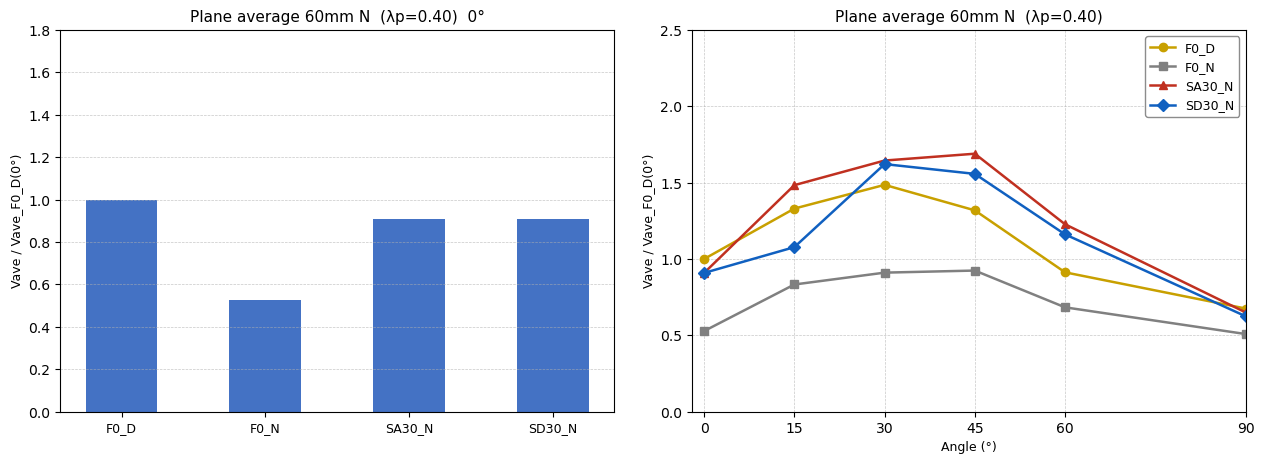

→ wind_tunnel_4cases.png に保存しました


In [9]:
# ══════════════════════════════════════════════════════════════
#  描画設定
# ══════════════════════════════════════════════════════════════
CASES = ['F0_D', 'F0_N', 'SA30_N', 'SD30_N']

COLORS = {
    'F0_D' : '#C8A000',   # gold
    'F0_N' : '#808080',   # gray
    'SA30_N': '#C03020',  # dark red
    'SD30_N': '#1060C0',  # blue
}
MARKERS = {
    'F0_D' : 'o',
    'F0_N' : 's',
    'SA30_N': '^',
    'SD30_N': 'D',
}

# ── 描画 ──────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.patch.set_facecolor('white')
title_str = 'Plane average 60mm N  (λp=0.40)'

# ─── 左: 棒グラフ（0° のみ）─────────────────────────────────
ax1 = axes[0]
vals_0 = [ratio[c][0] for c in CASES]
x = np.arange(len(CASES))

ax1.bar(x, vals_0, color='#4472C4', width=0.5)
ax1.set_title(f'{title_str}  0°', fontsize=11)
ax1.set_ylabel('Vave / Vave_F0_D(0°)', fontsize=9)
ax1.set_xticks(x)
ax1.set_xticklabels(CASES, fontsize=9)
ax1.set_ylim(0, 1.8)
ax1.yaxis.set_major_locator(ticker.MultipleLocator(0.2))
ax1.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.7)
ax1.set_facecolor('white')
for spine in ax1.spines.values():
    spine.set_linewidth(0.8)

# ─── 右: 折れ線グラフ（全角度）──────────────────────────────
ax2 = axes[1]

for case in CASES:
    ax2.plot(ANGLES, ratio[case],
             color=COLORS[case],
             marker=MARKERS[case],
             markersize=6,
             linewidth=1.8,
             label=case)

ax2.set_title(title_str, fontsize=11)
ax2.set_ylabel('Vave / Vave_F0_D(0°)', fontsize=9)
ax2.set_xlabel('Angle (°)', fontsize=9)
ax2.set_xlim(-2, 77)
ax2.set_xticks(ANGLES)
ax2.set_ylim(0, 2.5)
ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.5))
ax2.grid(linestyle='--', linewidth=0.5, alpha=0.7)
ax2.set_facecolor('white')
for spine in ax2.spines.values():
    spine.set_linewidth(0.8)
ax2.legend(fontsize=9, loc='upper right', framealpha=0.9, edgecolor='gray')

plt.tight_layout(pad=2.0)
plt.savefig('wind_tunnel_4cases.png', dpi=150, bbox_inches='tight')
plt.show()
print('→ wind_tunnel_4cases.png に保存しました')